# Install the Needed Libraries to Run Experiements

In [ ]:
%pip install -U gymnasium
%pip install -U ale-py
%pip install -U dopamine-rl

In [ ]:
%pip install jax[cuda12]==0.4.35

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 MB 15.8 MB/s eta 0:00:00
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.7.2
    Uninstalling jax-cuda12-pjrt-0.7.2:
      Successfully uninstalled jax-cuda12-pjrt-0.7.2
  Attempting uninstall: jax-cuda12-plugin
    Found existing installation: jax-cuda12-plugin 0.7.2
    Uninstalling jax-cuda12-plugin-0.7.2:
      Successfully uninstalled jax-cuda12-plugin-0.7.2
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2
ERROR: pi

In [ ]:
%pip install orbax-checkpoint==0.7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.7/279.7 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: orbax-checkpoint
    Found existing installation: orbax-checkpoint 0.11.34
    Uninstalling orbax-checkpoint-0.11.34:
      Successfully uninstalled orbax-checkpoint-0.11.34
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.11.2 requires jax>=0.6.0, but you have jax 0.4.35 which is incompatible.


# Run the Experiment - based on an example colab provided by Google at https://colab.research.google.com/github/google/dopamine/blob/master/dopamine/colab/agents.ipynb

In [ ]:
import numpy as np
import os
from dopamine.jax.agents.rainbow import rainbow_agent
from dopamine.discrete_domains import run_experiment
from dopamine.colab import utils as colab_utils
from absl import flags
import gin

BASE_PATH = '/content/dopamine_pong'  # @param
GAME = 'Pong'  # @param

# Where to store the checkpoints
LOG_PATH = os.path.join(BASE_PATH, 'rainbow_pong_run_1', GAME)
LOG_PATH2 = os.path.join(BASE_PATH, 'rainbow_pong_run_2', GAME)
LOG_PATH3 = os.path.join(BASE_PATH, 'rainbow_pong_run_3', GAME)

In [ ]:
# Creates Rainbow DQN agent with hyperparameters - hyperparameters provided by
# Dopamine GitHub repository - https://github.com/google/dopamine/blob/master/dopamine/jax/agents/rainbow/configs/rainbow.gin
def create_my_agent(unused_sess, environment, summary_writer=None):
    return rainbow_agent.JaxRainbowAgent(num_actions=environment.action_space.n,
                                         update_horizon=3,
                                         min_replay_history = 20000,
                                         update_period = 4,
                                         target_update_period=8000,
                                         replay_scheme='prioritized')
rainbow_dqn_config = """
import dopamine.discrete_domains.atari_lib
import dopamine.discrete_domains.run_experiment
atari_lib.create_atari_environment.game_name = '{}'
atari_lib.create_atari_environment.sticky_actions = True
run_experiment.Runner.num_iterations = 100
run_experiment.Runner.training_steps = 10000
run_experiment.Runner.evaluation_steps = 100
run_experiment.Runner.max_steps_per_episode = 27000
ReplayBuffer.max_capacity = 50000
PrioritizedSamplingDistribution.max_capacity = 50000
ReplayBuffer.batch_size = 32
create_optimizer.learning_rate = 0.0000625
create_optimizer.eps = 0.00015
""".format(GAME)

gin.parse_config(rainbow_dqn_config, skip_unknown=False)

# Run the experiment 3 times

#rainbow_dqn_runner1 = run_experiment.Runner(LOG_PATH, create_my_agent)
#rainbow_dqn_runner2 = run_experiment.Runner(LOG_PATH2, create_my_agent)
rainbow_dqn_runner3 = run_experiment.Runner(LOG_PATH3, create_my_agent)

In [ ]:
# @title Train.
print('Will train agent, please be patient, may be a while...')
#rainbow_dqn_runner1.run_experiment()
#rainbow_dqn_runner2.run_experiment()
rainbow_dqn_runner3.run_experiment()
print('Done training!')

Will train agent, please be patient, may be a while...


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Done training!


In [ ]:
# @title Load the training logs for runs 1, 2, and 3 - use "train_episode_returns" for training episode returns and "eval_episode_returns" for evaluation episode returns

# Load the training logs for run 1
rainbow_dqn_data = colab_utils.read_experiment(
    LOG_PATH, verbose=True, summary_keys=['train_episode_returns'])
rainbow_dqn_data['agent'] = 'RainbowDQN Run 1'
rainbow_dqn_data['run_number'] = 1
experimental_data = {GAME:  rainbow_dqn_data}

# @title Load the training logs for run 2.
rainbow_dqn_data2 = colab_utils.read_experiment(
    LOG_PATH2, verbose=True, summary_keys=['train_episode_returns'])
rainbow_dqn_data2['agent'] = 'RainbowDQN Run 2'
rainbow_dqn_data2['run_number'] = 1
experimental_data2 = {GAME:  rainbow_dqn_data2}

# @title Load the training logs for run 3.
rainbow_dqn_data3 = colab_utils.read_experiment(
    LOG_PATH3, verbose=True, summary_keys=['train_episode_returns'])
rainbow_dqn_data3['agent'] = 'RainbowDQN Run 3'
rainbow_dqn_data3['run_number'] = 1
experimental_data3 = {GAME:  rainbow_dqn_data3}

Reading statistics from: /content/dopamine_pong/rainbow_pong_run_1/Pong//logs/log_99
Reading statistics from: /content/dopamine_pong/rainbow_pong_run_2/Pong//logs/log_99
Reading statistics from: /content/dopamine_pong/rainbow_pong_run_3/Pong//logs/log_99


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


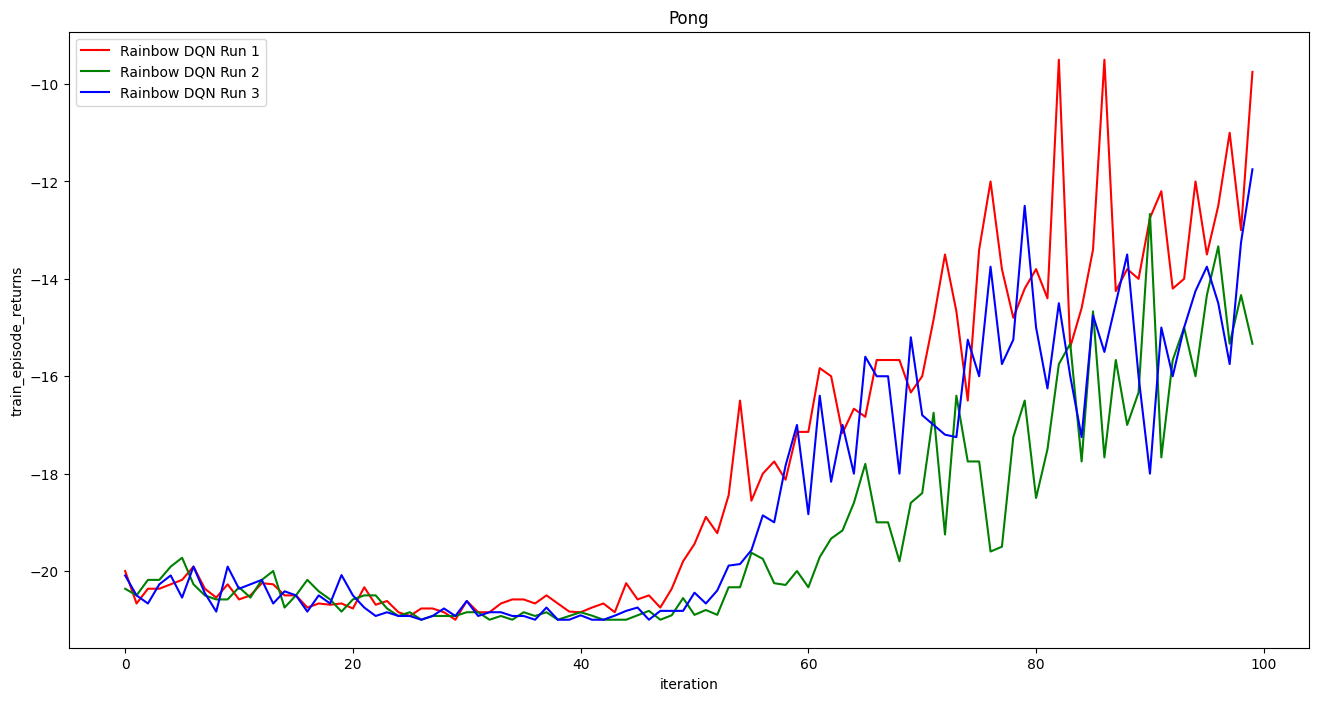

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# @title Plot training results.

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,8))
sns.lineplot(
    x='iteration', y='train_episode_returns',
    data=experimental_data[GAME], ax=ax, color='red', label='Rainbow DQN Run 1')
sns.lineplot(
    x='iteration', y='train_episode_returns',
    data=experimental_data2[GAME], ax=ax, color='green', label='Rainbow DQN Run 2')
sns.lineplot(
    x='iteration', y='train_episode_returns',
    data=experimental_data3[GAME], ax=ax, color='blue', label='Rainbow DQN Run 3')
plt.title(GAME)
plt.show()